In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

LOAD THE DATA

In [84]:
transactions = pd.read_csv(r"C:\Users\SASWAT\OneDrive\Desktop\PHONEPAY\all_transactions.csv")

users = pd.read_csv(r"C:\Users\SASWAT\OneDrive\Desktop\PHONEPAY\all_users - Copy.csv")

check data

Transactions data overview

In [85]:
transactions.head(10)


,Transaction_ID,Amount,User_ID,Service,Service Type,Payment_Status,Reason,Date
0,RCG_0C338474B366,926.59,PP0021371,Recharge_Bills,FASTag Recharge,Successful,Successful,09-06-2024
1,RCG_6B3B86B07A76,1211.64,PP0002388,Recharge_Bills,DTH,Successful,Successful,04-08-2024
2,RCG_767822392A0E,746.27,PP1101831,Recharge_Bills,Cable TV,Successful,Successful,19-02-2024
3,RCG_527E6AC74B11,1319.89,PP0033099,Recharge_Bills,Mobile Recharge,Successful,Successful,22-12-2024
4,RCG_6B50A8C694E1,112.44,PP1059869,Recharge_Bills,Cable TV,Successful,Successful,07-09-2024
5,RCG_E63DCBDBB8C9,1278.95,PP1093720,Recharge_Bills,FASTag Recharge,Successful,Successful,25-07-2024
6,RCG_DD16B3117FB9,1206.69,PP1067328,Recharge_Bills,FASTag Recharge,Successful,Successful,06-08-2024
7,RCG_654D31ECCDC2,1945.11,PP0041770,Recharge_Bills,FASTag Recharge,Successful,Successful,23-04-2024
8,RCG_6C53A7808151,1684.57,PP0017979,Recharge_Bills,FASTag Recharge,Successful,Successful,25-06-2024
9,RCG_92AE572161FA,1954.71,PP1085390,Recharge_Bills,DTH,Successful,Successful,20-11-2024


In [86]:
transactions.tail()

,Transaction_ID,Amount,User_ID,Service,Service Type,Payment_Status,Reason,Date
299995,INS_24E64F9B7299,13071.42,PP0028490,Insurance,Bike,Successful,Successful,07-01-2024
299996,INS_3BE29AC5D50A,15401.86,PP0014627,Insurance,Term Life,Successful,Successful,29-08-2024
299997,INS_DABD5CA9E4DB,10671.15,PP1082547,Insurance,Health,Successful,Successful,05-08-2024
299998,INS_551C3CA76408,4041.38,PP1064893,Insurance,Bike,Failed,Wrong PIN,14-05-2024
299999,INS_1D03CAE7E0F6,5118.85,PP0049481,Insurance,Term Life,Successful,Successful,02-03-2024


In [87]:
transactions.shape

(300000, 8)

In [88]:
transactions.columns

Index(['Transaction_ID', 'Amount', 'User_ID', 'Service', 'Service Type',
       'Payment_Status', 'Reason', 'Date'],
      dtype='str')

In [89]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Transaction_ID  300000 non-null  str    
 1   Amount          300000 non-null  float64
 2   User_ID         300000 non-null  str    
 3   Service         300000 non-null  str    
 4   Service Type    300000 non-null  str    
 5   Payment_Status  300000 non-null  str    
 6   Reason          300000 non-null  str    
 7   Date            300000 non-null  str    
dtypes: float64(1), str(7)
memory usage: 18.3 MB


In [90]:
transactions.describe()

,Amount
count,300000.000000
mean,11581.073114
std,21376.115812
min,20.000000
25%,1345.587500
50%,3091.450000
75%,8769.805000
max,99999.010000


Users data overview

In [91]:
users.head()

,User_ID,Name,Age,Join_Date
0,PP0000001,Holly Rivera,56,2025-06-17
1,PP0000002,Kevin Lopez,46,2023-12-10
2,PP0000003,Douglas Roberts,32,2024-09-14
3,PP0000004,Walter Davila,60,2023-10-19
4,PP0000005,Grace Blake,25,2025-03-10


In [92]:
users.tail()

,User_ID,Name,Age,Join_Date
107653,PP1107653,Dennis Brewer,60,2024-10-08
107654,PP1107654,Janice Wilson,40,2024-08-12
107655,PP1107655,Dustin Hays,53,2025-06-05
107656,PP1107656,Kathleen Gonzalez,27,2024-01-19
107657,PP1107657,Deanna Jones,44,2024-05-22


In [93]:
users.shape

(107658, 4)

In [94]:
users.tail()

,User_ID,Name,Age,Join_Date
107653,PP1107653,Dennis Brewer,60,2024-10-08
107654,PP1107654,Janice Wilson,40,2024-08-12
107655,PP1107655,Dustin Hays,53,2025-06-05
107656,PP1107656,Kathleen Gonzalez,27,2024-01-19
107657,PP1107657,Deanna Jones,44,2024-05-22


In [95]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 107658 entries, 0 to 107657
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   User_ID    107658 non-null  str  
 1   Name       107658 non-null  str  
 2   Age        107658 non-null  int64
 3   Join_Date  107658 non-null  str  
dtypes: int64(1), str(3)
memory usage: 3.3 MB


In [96]:
users.describe()

,Age
count,107658.000000
mean,39.034628
std,12.382832
min,18.000000
25%,28.000000
50%,39.000000
75%,50.000000
max,60.000000


          DATA CLEANING PART

In [97]:
transactions.isnull().sum()

Transaction_ID    0
Amount            0
User_ID           0
Service           0
Service Type      0
Payment_Status    0
Reason            0
Date              0
dtype: int64

In [98]:
users.isnull().sum()

User_ID      0
Name         0
Age          0
Join_Date    0
dtype: int64

DUPLICATE CHECK

In [99]:
transactions.duplicated().sum()

np.int64(0)

In [100]:
users.duplicated().sum()

np.int64(0)

Check Unique IDs

In [101]:
transactions["Transaction_ID"].duplicated().sum()

np.int64(0)

In [102]:
users["User_ID"].duplicated().sum()

np.int64(0)

Convert Date Columns

In [103]:
##Date column clean 
transactions["Date"] = transactions["Date"].astype(str).str.strip()

In [104]:
transactions["Date"] = pd.to_datetime(
    transactions["Date"],
    dayfirst=True,
    errors="raise"
)

In [105]:
print(transactions["Date"].dtype)

datetime64[us]


In [106]:
##Date column clean 
users["Join_Date"] = users["Join_Date"].astype(str).str.strip()

In [107]:
users["Join_Date"] = pd.to_datetime(
    users["Join_Date"],
    dayfirst=True,
    errors="raise"
)

C:\Users\SASWAT\AppData\Local\Temp\ipykernel_11964\2588608185.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  users["Join_Date"] = pd.to_datetime(


In [108]:
print(users["Join_Date"].dtype)

datetime64[us]


In [109]:
users.head()

,User_ID,Name,Age,Join_Date
0,PP0000001,Holly Rivera,56,2025-06-17
1,PP0000002,Kevin Lopez,46,2023-12-10
2,PP0000003,Douglas Roberts,32,2024-09-14
3,PP0000004,Walter Davila,60,2023-10-19
4,PP0000005,Grace Blake,25,2025-03-10


Merge Both Tables

In [110]:
df = pd.merge(
    transactions,
    users,
    on="User_ID",
    how="left"
)

In [111]:
df.head()

,Transaction_ID,Amount,User_ID,Service,Service Type,Payment_Status,Reason,Date,Name,Age,Join_Date
0,RCG_0C338474B366,926.59,PP0021371,Recharge_Bills,FASTag Recharge,Successful,Successful,2024-06-09,Katherine Howard,50,2023-08-28
1,RCG_6B3B86B07A76,1211.64,PP0002388,Recharge_Bills,DTH,Successful,Successful,2024-08-04,Kimberly Mueller,34,2024-08-10
2,RCG_767822392A0E,746.27,PP1101831,Recharge_Bills,Cable TV,Successful,Successful,2024-02-19,Scott Davis,36,2023-09-28
3,RCG_527E6AC74B11,1319.89,PP0033099,Recharge_Bills,Mobile Recharge,Successful,Successful,2024-12-22,Gina Williams,25,2023-10-09
4,RCG_6B50A8C694E1,112.44,PP1059869,Recharge_Bills,Cable TV,Successful,Successful,2024-09-07,Timothy Hernandez,58,2024-07-13


In [112]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Transaction_ID  300000 non-null  str           
 1   Amount          300000 non-null  float64       
 2   User_ID         300000 non-null  str           
 3   Service         300000 non-null  str           
 4   Service Type    300000 non-null  str           
 5   Payment_Status  300000 non-null  str           
 6   Reason          300000 non-null  str           
 7   Date            300000 non-null  datetime64[us]
 8   Name            300000 non-null  str           
 9   Age             300000 non-null  int64         
 10  Join_Date       300000 non-null  datetime64[us]
dtypes: datetime64[us](2), float64(1), int64(1), str(7)
memory usage: 25.2 MB


In [113]:
df["User_ID"].unique()

<StringArray>
['PP0021371', 'PP0002388', 'PP1101831', 'PP0033099', 'PP1059869', 'PP1093720',
 'PP1067328', 'PP0041770', 'PP0017979', 'PP1085390',
 ...
 'PP1101688', 'PP1057152', 'PP1060204', 'PP0026315', 'PP0040820', 'PP0029673',
 'PP1082723', 'PP0020320', 'PP1059675', 'PP1090475']
Length: 100761, dtype: str

In [114]:
print("Transactions Missing User_ID :", transactions["User_ID"].isnull().sum())

print("Users Missing User_ID :", users["User_ID"].isnull().sum())

Transactions Missing User_ID : 0
Users Missing User_ID : 0


In [115]:
matched = transactions["User_ID"].isin(users["User_ID"])

print("Matched User_ID :", matched.sum())
print("Not Matched User_ID :", (~matched).sum())

Matched User_ID : 300000
Not Matched User_ID : 0


In [116]:
transactions.loc[~transactions["User_ID"].isin(users["User_ID"]), "User_ID"].unique()

<StringArray>
[]
Length: 0, dtype: str

                                          ANALYSIS PART

In [117]:
df.head()

,Transaction_ID,Amount,User_ID,Service,Service Type,Payment_Status,Reason,Date,Name,Age,Join_Date
0,RCG_0C338474B366,926.59,PP0021371,Recharge_Bills,FASTag Recharge,Successful,Successful,2024-06-09,Katherine Howard,50,2023-08-28
1,RCG_6B3B86B07A76,1211.64,PP0002388,Recharge_Bills,DTH,Successful,Successful,2024-08-04,Kimberly Mueller,34,2024-08-10
2,RCG_767822392A0E,746.27,PP1101831,Recharge_Bills,Cable TV,Successful,Successful,2024-02-19,Scott Davis,36,2023-09-28
3,RCG_527E6AC74B11,1319.89,PP0033099,Recharge_Bills,Mobile Recharge,Successful,Successful,2024-12-22,Gina Williams,25,2023-10-09
4,RCG_6B50A8C694E1,112.44,PP1059869,Recharge_Bills,Cable TV,Successful,Successful,2024-09-07,Timothy Hernandez,58,2024-07-13


In [118]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Transaction_ID  300000 non-null  str           
 1   Amount          300000 non-null  float64       
 2   User_ID         300000 non-null  str           
 3   Service         300000 non-null  str           
 4   Service Type    300000 non-null  str           
 5   Payment_Status  300000 non-null  str           
 6   Reason          300000 non-null  str           
 7   Date            300000 non-null  datetime64[us]
 8   Name            300000 non-null  str           
 9   Age             300000 non-null  int64         
 10  Join_Date       300000 non-null  datetime64[us]
dtypes: datetime64[us](2), float64(1), int64(1), str(7)
memory usage: 25.2 MB


In [121]:
df.describe()

,Amount,Date,Age,Join_Date
count,300000.000000,300000,300000.000000,300000
mean,11581.073114,2024-07-01 00:46:23.520000,39.065843,2024-08-01 03:24:31.680000
min,20.000000,2024-01-01 00:00:00,18.000000,2023-08-03 00:00:00
25%,1345.587500,2024-04-01 00:00:00,28.000000,2024-02-01 00:00:00
50%,3091.450000,2024-07-01 00:00:00,39.000000,2024-07-31 00:00:00
75%,8769.805000,2024-10-01 00:00:00,50.000000,2025-01-30 00:00:00
max,99999.010000,2024-12-30 00:00:00,60.000000,2025-08-02 00:00:00
std,21376.115812,NaN,12.397426,NaN


In [123]:
df["User_ID"].unique()

<StringArray>
['PP0021371', 'PP0002388', 'PP1101831', 'PP0033099', 'PP1059869', 'PP1093720',
 'PP1067328', 'PP0041770', 'PP0017979', 'PP1085390',
 ...
 'PP1101688', 'PP1057152', 'PP1060204', 'PP0026315', 'PP0040820', 'PP0029673',
 'PP1082723', 'PP0020320', 'PP1059675', 'PP1090475']
Length: 100761, dtype: str

In [124]:
df["User_ID"].count()

np.int64(300000)

In [126]:
df["Payment_Status"].unique()

<StringArray>
['Successful', 'Failed', 'Wrong PIN', 'Insufficient amount', 'Server error']
Length: 5, dtype: str

KPI ANALYSIS

In [129]:
print("Total Transactions :", len(df))
print("Unique Users :", df["User_ID"].nunique())
print("Total Transaction Amount Billion :", round(df["Amount"].sum()/1000000000,2))
print("Average Transaction Amount :", round(df["Amount"].mean(),2))
print("Median Transaction Amount :", df["Amount"].median())
print("Maximum Transaction :", df["Amount"].max())
print("Minimum Transaction :", df["Amount"].min())
print("Standard Deviation :", round(df["Amount"].std(),2))

Total Transactions : 300000
Unique Users : 100761
Total Transaction Amount Billion : 3.47
Average Transaction Amount : 11581.07
Median Transaction Amount : 3091.45
Maximum Transaction : 99999.01
Minimum Transaction : 20.0
Standard Deviation : 21376.12


In [131]:
##Payment Status Analysis
df["Payment_Status"].value_counts()



Payment_Status
Successful             287993
Failed                   9980
Wrong PIN                 700
Server error              692
Insufficient amount       635
Name: count, dtype: int64

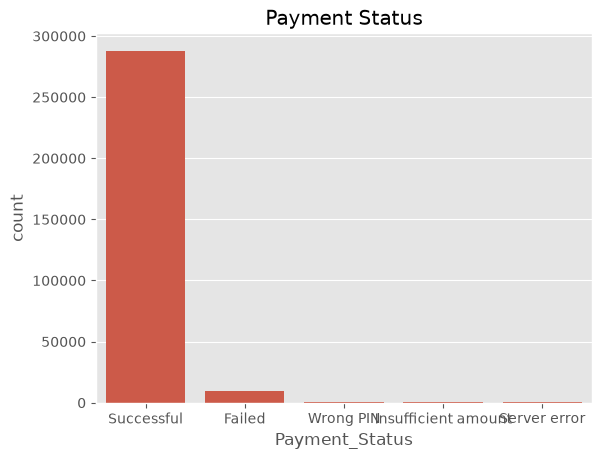

In [132]:

##Visualization

sns.countplot(data=df, x="Payment_Status")
plt.title("Payment Status")
plt.show()

In [133]:
##percentage
round(df["Payment_Status"].value_counts(normalize=True)*100,2)

Payment_Status
Successful             96.00
Failed                  3.33
Wrong PIN               0.23
Server error            0.23
Insufficient amount     0.21
Name: proportion, dtype: float64

In [135]:
##Service Analysis
df["Service"].value_counts()



Service
Money_Transfer    150000
Recharge_Bills     50000
Loans              50000
Insurance          50000
Name: count, dtype: int64

In [137]:
##Revenue by Service

df.groupby("Service")["Amount"].sum().sort_values(ascending=False)



Service
Loans             2.532509e+09
Insurance         5.129230e+08
Money_Transfer    3.781946e+08
Recharge_Bills    5.069497e+07
Name: Amount, dtype: float64

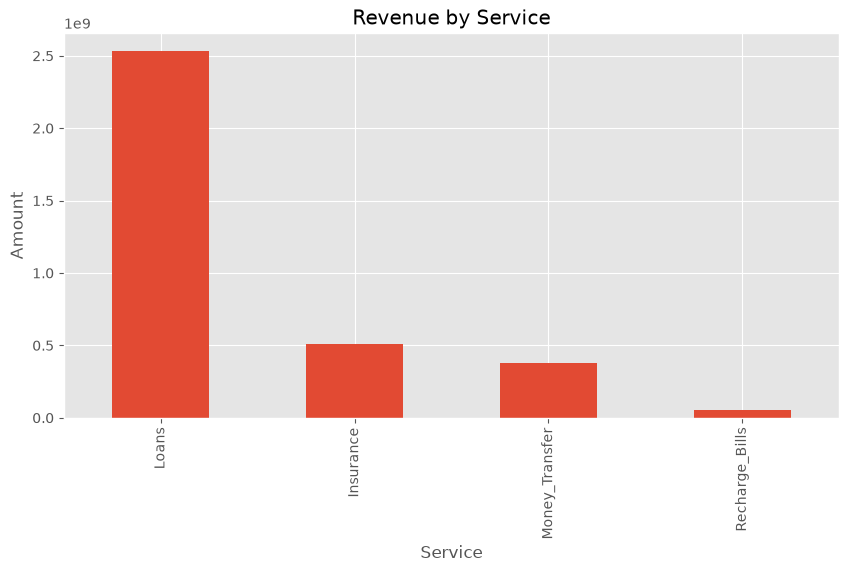

In [138]:
##Visualization

service_amount = df.groupby("Service")["Amount"].sum().sort_values(ascending=False)

service_amount.plot(kind="bar", figsize=(10,5))
plt.title("Revenue by Service")
plt.ylabel("Amount")
plt.show()

In [139]:
##Service Type Analysis
df["Service Type"].value_counts()

Service Type
To UPI ID           37611
To Self Account     37516
To Mobile Number    37476
To QR Code          37397
Bike Loan           12689
FASTag Recharge     12598
Term Life           12593
Car                 12585
Cable TV            12516
Bike                12501
Mutual Fund         12481
Gold Loan           12473
DTH                 12471
Mobile Recharge     12415
Credit Score        12357
Health              12321
Name: count, dtype: int64

In [141]:
##Revenue

df.groupby("Service Type")["Amount"].sum().sort_values(ascending=False)



Service Type
Bike Loan           6.436441e+08
Mutual Fund         6.342093e+08
Gold Loan           6.324125e+08
Credit Score        6.222435e+08
Car                 1.293481e+08
Term Life           1.288615e+08
Bike                1.281032e+08
Health              1.266101e+08
To UPI ID           9.519371e+07
To Self Account     9.440188e+07
To QR Code          9.431098e+07
To Mobile Number    9.428807e+07
FASTag Recharge     1.281511e+07
DTH                 1.263572e+07
Mobile Recharge     1.263093e+07
Cable TV            1.261321e+07
Name: Amount, dtype: float64

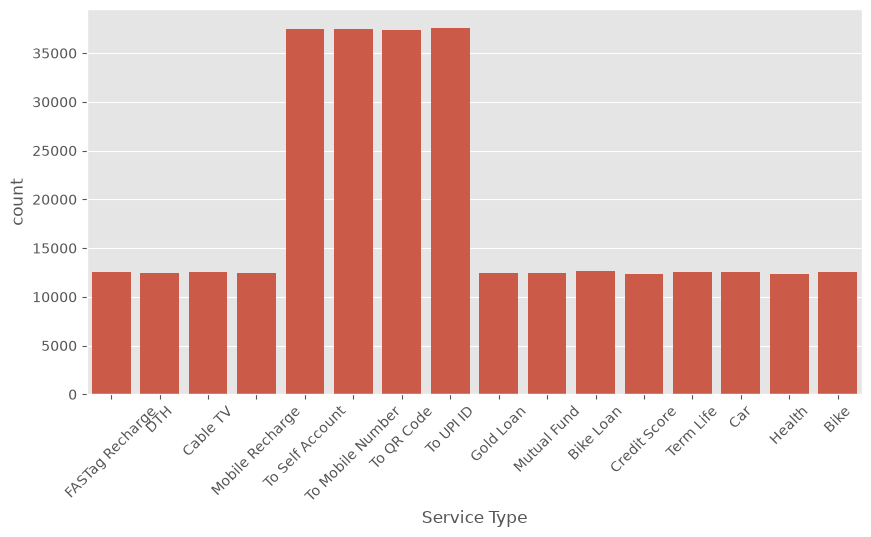

In [142]:
##Visualization

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Service Type")
plt.xticks(rotation=45)
plt.show()

In [144]:
##Reason Analysis
df["Reason"].value_counts()



Reason
Successful             287993
Server error             4053
Wrong PIN                3315
Insufficient amount      3304
Wrong Info                700
Bank Denied               635
Name: count, dtype: int64

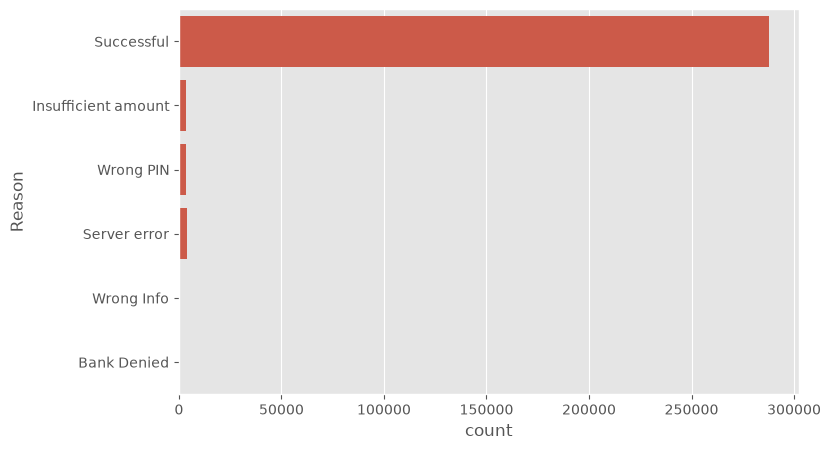

In [145]:
##Visualization

plt.figure(figsize=(8,5))
sns.countplot(data=df, y="Reason")
plt.show()

In [147]:
##Amount Analysis
##Statistics

round(df["Amount"].describe(),2)

count    300000.00
mean      11581.07
std       21376.12
min          20.00
25%        1345.59
50%        3091.45
75%        8769.80
max       99999.01
Name: Amount, dtype: float64

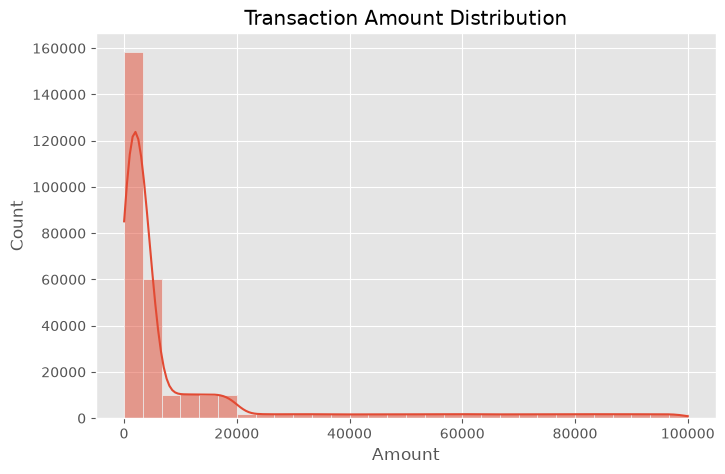

In [148]:
##Histogram

plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=30, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

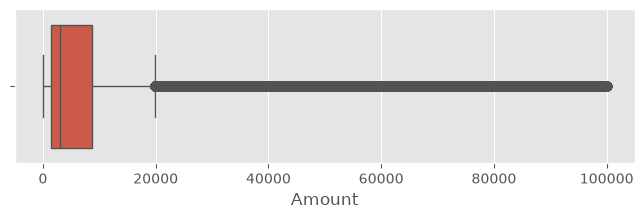

In [149]:
##Boxplot

plt.figure(figsize=(8,2))
sns.boxplot(x=df["Amount"])
plt.show()

User Analysis

In [150]:
##Top 10 Users

df.groupby("Name")["Amount"].sum().sort_values(ascending=False).head(10)

Name
Michael Smith        1817706.21
Jennifer Williams    1567635.26
Michael Brown        1273099.49
Christopher Brown    1232907.35
Michael Jones        1210406.36
Robert Smith         1199850.73
Christopher Smith    1099431.38
James Johnson        1074389.72
John Smith           1065267.62
Jennifer Smith       1049159.54
Name: Amount, dtype: float64

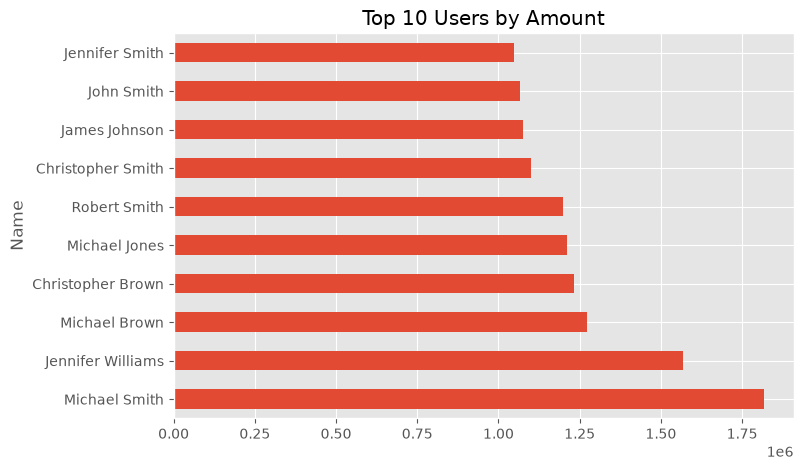

In [151]:
##Visualization

top10 = df.groupby("Name")["Amount"].sum().sort_values(ascending=False).head(10)

top10.plot(kind="barh", figsize=(8,5))
plt.title("Top 10 Users by Amount")
plt.show()

In [153]:
##Age Analysis

##Create Age Group

bins=[0,18,30,45,60,100]

labels=["0-18","19-30","31-45","46-60","60+"]

df["Age_Group"]=pd.cut(df["Age"],bins=bins,labels=labels)

In [154]:
##Transactions by Age Group

df["Age_Group"].value_counts()

Age_Group
46-60    105129
31-45    104869
19-30     83111
0-18       6891
60+           0
Name: count, dtype: int64

In [155]:
##Amount by Age Group

df.groupby("Age_Group")["Amount"].sum()

Age_Group
0-18     8.198418e+07
19-30    9.616652e+08
31-45    1.214900e+09
46-60    1.215772e+09
Name: Amount, dtype: float64

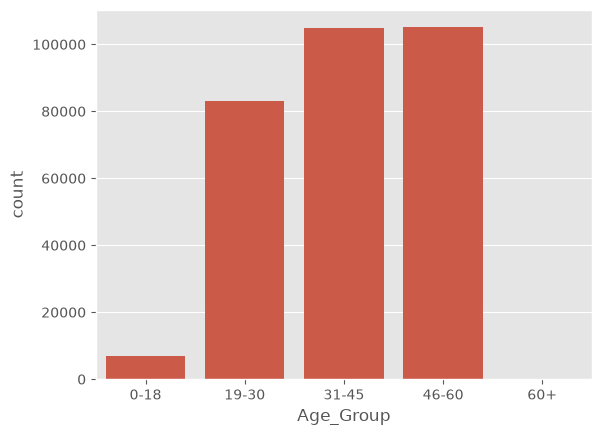

In [156]:
##Visualization

sns.countplot(data=df,x="Age_Group")
plt.show()

Monthly Analysis

In [157]:
df["Month"]=df["Date"].dt.to_period("M")

In [158]:
monthly=df.groupby("Month")["Amount"].sum()

monthly

Month
2024-01    2.934558e+08
2024-02    2.788757e+08
2024-03    2.927008e+08
2024-04    2.835865e+08
2024-05    2.960572e+08
2024-06    2.863175e+08
2024-07    3.044851e+08
2024-08    2.902145e+08
2024-09    2.829055e+08
2024-10    2.949422e+08
2024-11    2.846212e+08
2024-12    2.861599e+08
Freq: M, Name: Amount, dtype: float64

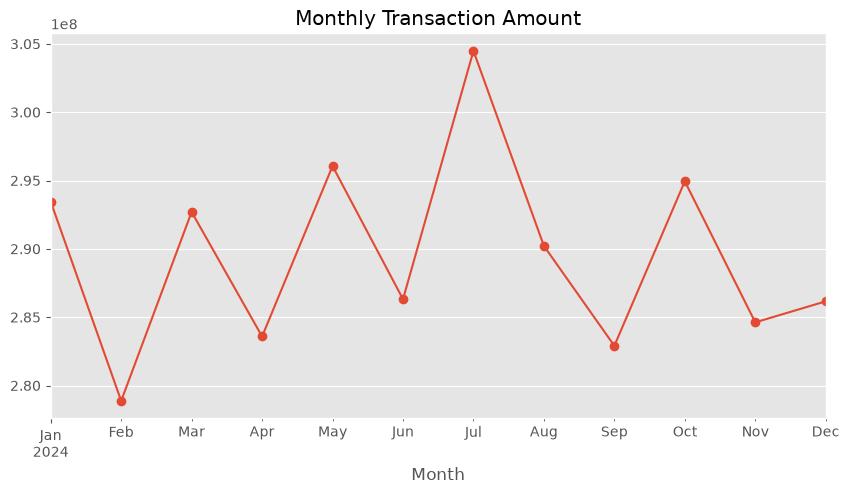

In [160]:
##visualization
monthly.plot(marker="o",figsize=(10,5))
plt.title("Monthly Transaction Amount")
plt.show()

In [161]:
##Correlation
corr=df.select_dtypes(include="number").corr()

corr

,Amount,Age
Amount,1.000000,-0.000916
Age,-0.000916,1.000000


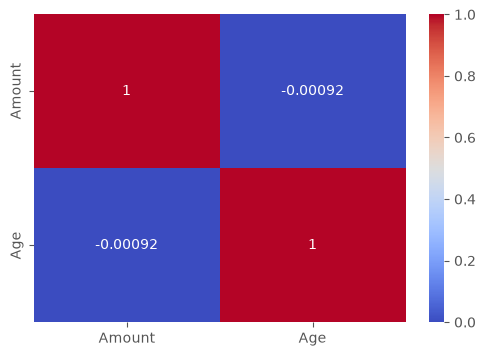

In [162]:
plt.figure(figsize=(6,4))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.show()

         Business Insights

1. Transaction Overview

Total Transactions: 300,000

Unique Users: 100,761

Total Transaction Value: 3.47 Billion

Average Transaction Amount: 11,581.07

Median Transaction Amount: 3,091.45

Highest Transaction Amount: 99,999.01

Lowest Transaction Amount: 20.00

Insight:
The platform processed 300,000 transactions with a total transaction value of 3.47 billion. The average transaction amount (11,581.07) is significantly higher than the median (3,091.45), indicating a right-skewed distribution caused by a relatively small number of high-value transactions.

2. Payment Status Analysis

Payment Status	   Count	      Percentage
Successful	     287,993	          96.00%
Failed	           9,980	           3.33%
Wrong PIN	        700	               0.23%
Server Error	    692	               0.23%
Insufficient Amount	635	               0.21%

Insight:

The platform achieved a 96% payment success rate, demonstrating strong operational reliability.
Only 4% of transactions experienced issues.
Most failed transactions were categorized as Failed, while Wrong PIN, Server Error, and Insufficient Amount accounted for a relatively small proportion.

3. Service Analysis
   
Transaction Count
Service	Transactions
Money Transfer	150,000
Recharge Bills	50,000
Loans	50,000
Insurance	50,000
Revenue by Service
Service	Revenue
Loans	2.53 Billion
Insurance	0.51 Billion
Money Transfer	0.38 Billion
Recharge Bills	0.05 Billion

Insight:

Money Transfer was the most frequently used service.
Loans generated the highest revenue, making it the most valuable business segment.

4. Service Type Analysis

The highest revenue-generating service types were:

Bike Loan
Mutual Fund
Gold Loan
Credit Score

Insight:
Financial products contributed significantly more revenue than recharge-related services.

5. Failure Reason Analysis

Top failure reasons:

Server Error
Wrong PIN
Insufficient Amount
Wrong Information
Bank Denied

Insight:
Most unsuccessful transactions resulted from either technical issues or user input errors.

6. User Analysis

Top customer by transaction value:

Michael Smith

Insight:
A small group of users generated a disproportionately high share of the total transaction value, indicating the presence of high-value customers.

7. Age Group Analysis
Age Group	Transaction Value
46–60	1.216 Billion
31–45	1.215 Billion
19–30	0.962 Billion
0–18	0.082 Billion

Insight:
Users aged 31–60 years contributed the highest transaction value, making them the platform's most valuable customer segment.

8. Monthly Transaction Trend

Highest transaction value: July 2024
Lowest transaction value: February 2024

Insight:
Transaction values remained relatively stable throughout the year, with only minor monthly fluctuations.

Correlation Analysis

Variables	Correlation
Amount vs Age	-0.0009

Interpretation
The correlation coefficient between Age and Transaction Amount is -0.0009, which is extremely close to zero.

Insight:

There is no significant linear relationship between customer age and transaction amount.
Age does not appear to influence transaction value in this dataset.
    
Overall Conclusion
The platform processed 300,000 transactions from 100,761 unique users, generating a total transaction value of 3.47 billion.
A 96% payment success rate indicates excellent platform reliability and operational performance.
Money Transfer was the most frequently used service, while Loans generated the highest revenue.
Financial services such as Bike Loan, Mutual Fund, and Gold Loan contributed the largest share of transaction value.
Customers aged 31–60 years represented the most valuable customer segment.
Transaction values remained stable throughout 2024, with July recording the highest monthly transaction value.
The transaction amount distribution is right-skewed, as the average transaction amount is considerably higher than the median due to high-value transactions.
Correlation analysis confirmed no meaningful relationship between customer age and transaction amount.

These findings indicate that the platform is operationally reliable, financially driven by loan-related services, and supported primarily by middle-aged customers with consistent transaction activity throughout the year.